# Uczenie Maszynowe

## Sprawozdanie - lab0: Wprowadzenie do Pythona

### 1. Import bibliotek

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ucimlrepo import fetch_ucirepo

### 2. Zbiór danych IRIS

#### 2.1 Wczytanie danych

In [26]:
iris = fetch_ucirepo(id=53)

# data
X_iris = iris.data.features
y_iris = iris.data.targets

df_iris = pd.concat([X_iris, y_iris], axis=1)
df_iris.columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']

df_iris.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


#### 2.2 Analiza struktury zbioru IRIS

In [27]:
print(f'klasy: {np.unique(y_iris)}')
print(f'liczba klas: {df_iris["class"].nunique()}')
print(f'instancje: {len(df_iris)}')
print(f'cechy: {X_iris.shape[1]}')
print()

print('Klasy i liczba probek w kazdej klasie:')
print(df_iris['class'].value_counts())
print()

print('Brakujace wartosci w zbiorze:')
print(df_iris.isnull().sum())
print()

print('Statystyki opisowe:')
df_iris.describe()

klasy: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
liczba klas: 3
instancje: 150
cechy: 4

Klasy i liczba probek w kazdej klasie:
class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Brakujace wartosci w zbiorze:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
class           0
dtype: int64

Statystyki opisowe:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


#### 2.3 Wizualizacje

* dystrybucja klas w zbiorze:

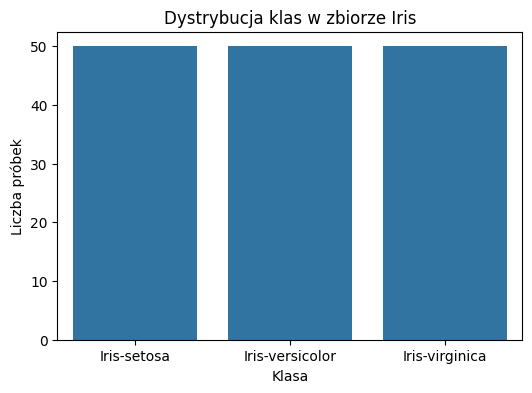

In [28]:
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df_iris)
plt.title('Dystrybucja klas w zbiorze Iris')
plt.xlabel('Klasa')
plt.ylabel('Liczba próbek')
plt.show()

-- idealnie zbalansowany zbiór

* wykres zalezności długości/szerokości płatków IRIS a klasą (z kolorem)

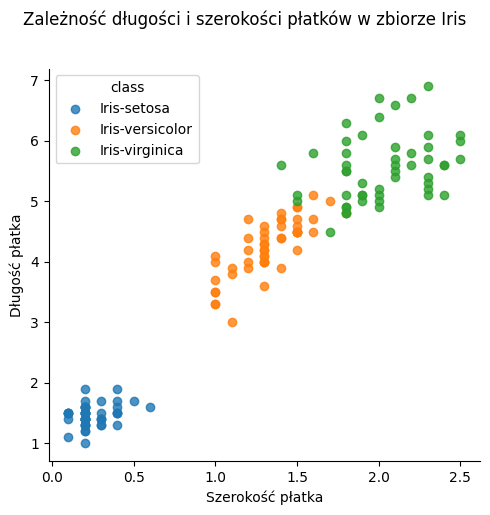

In [29]:
g = sns.lmplot(
    data=df_iris,
    x='petal_width', 
    y='petal_length', 
    hue='class',
    facet_kws=dict(legend_out=False),
    fit_reg=False
)
g.set_axis_labels('Szerokość płatka', 'Długość płatka')
g.figure.suptitle('Zależność długości i szerokości płatków w zbiorze Iris', y=1.02)
plt.tight_layout()
plt.show()

* wykres zaleznosci dlugosci/szerokosci kielicha IRIS a klasa (z kolorem)

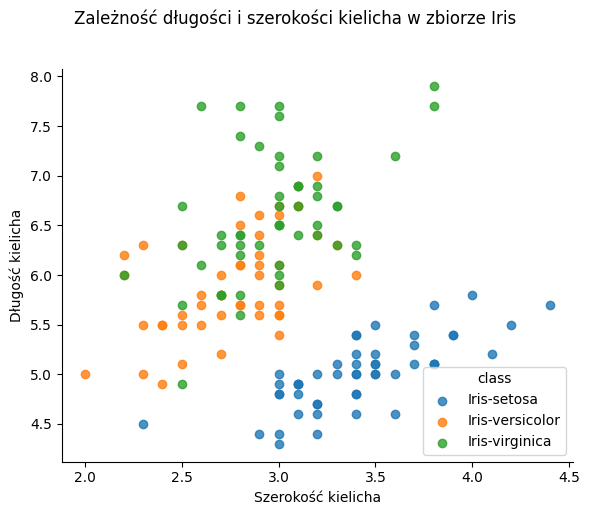

In [30]:
g = sns.lmplot(
    data=df_iris,
    x='sepal_width',
    y='sepal_length',
    hue='class',
    aspect=1.2,
    facet_kws=dict(legend_out=False),
    fit_reg=False
)
g.set_axis_labels('Szerokość kielicha', 'Długość kielicha')
g.figure.suptitle('Zależność długości i szerokości kielicha w zbiorze Iris', y=1.02)
plt.tight_layout()
plt.show()

-- zalezności długości/szerokości płatków pozwalają na łatwiejsze pogrupowanie klas niz zalezności kielicha

* Zalezności między wszystkimi parami atrybotów dla IRIR

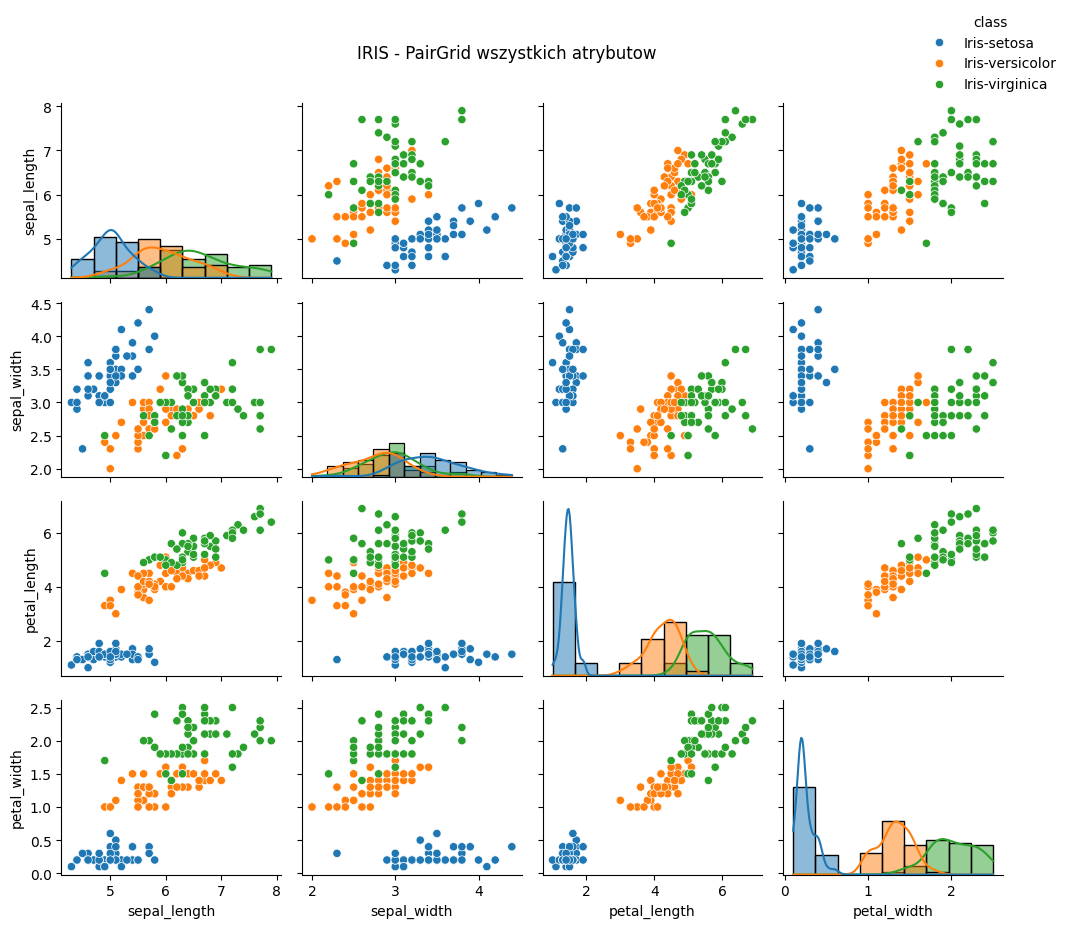

In [31]:
g = sns.PairGrid(df_iris, hue='class', height=2.2)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
g.map_diag(sns.histplot, kde=True)
g.add_legend(title='class', bbox_to_anchor=(1.05, 1))
g.figure.suptitle('IRIS - PairGrid wszystkich atrybutow', y=1.01)
plt.tight_layout()
plt.show()

-- dwie klasy są do siebie podobne i lekko nachodzą na siebie w przestrzeni cech - co moze utrudnić klasyfikację (jednak i tak widoczny jest podział)

-- jedna klasa (setosa) jest bardzo dobrze oddzielona od pozostałych

-- równy podział klas, mało cech, dobrze separowalne grupy

### 3. Zbiór danych GLASS

#### 3.1 Wczytanie danych

Wartości dla danych pierwiastków to procent wagowy w odpowiednim tlenku

Typy klas:

    - 1 building_windows_float_processed

    - 2 building_windows_non_float_processed

    - 3 vehicle_windows_float_processed

    - 4 vehicle_windows_non_float_processed (none in this database)

    - 5 containers

    - 6 tableware

    - 7 headlamps


In [32]:
glass_repo = fetch_ucirepo(id=42)

X_glass = glass_repo.data.features
y_glass = glass_repo.data.targets

df_glass = pd.concat([X_glass, y_glass], axis=1)

df_glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type_of_glass
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


#### 3.2 Analiza struktury zbioru GLASS

In [33]:
print(f'klasy: {np.unique(y_glass)}')
print(f'liczba klas: {df_glass.iloc[:, -1].nunique()}')
print(f'instancje: {len(df_glass)}')
print(f'cechy: {X_glass.shape[1]}')
print()

print('Klasy i liczba probek w kazdej klasie:')
print(df_glass.iloc[:, -1].value_counts())
print()

print('Brakujace wartosci w zbiorze:')
print(df_glass.isnull().sum())
print()

print('Statystyki opisowe:')
df_glass.describe()

klasy: [1 2 3 5 6 7]
liczba klas: 6
instancje: 214
cechy: 9

Klasy i liczba probek w kazdej klasie:
Type_of_glass
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64

Brakujace wartosci w zbiorze:
RI               0
Na               0
Mg               0
Al               0
Si               0
K                0
Ca               0
Ba               0
Fe               0
Type_of_glass    0
dtype: int64

Statystyki opisowe:


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type_of_glass
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


#### 3.3 Wizualizacje

* dystrybucja klas w zbiorze

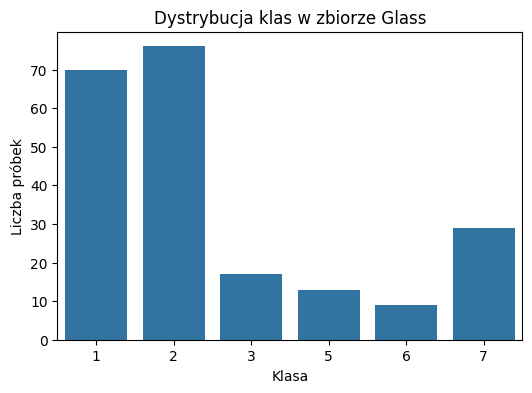

In [34]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df_glass.columns[-1], data=df_glass)
plt.title('Dystrybucja klas w zbiorze Glass')
plt.xlabel('Klasa')
plt.ylabel('Liczba próbek')
plt.show()

-- bardzo nierównomierny rozkład klas, moze prowadzić do ignorowania klas mniejszościowych

* wykres zalezności atrybutów (RI, Ca) dla zbioru Glass

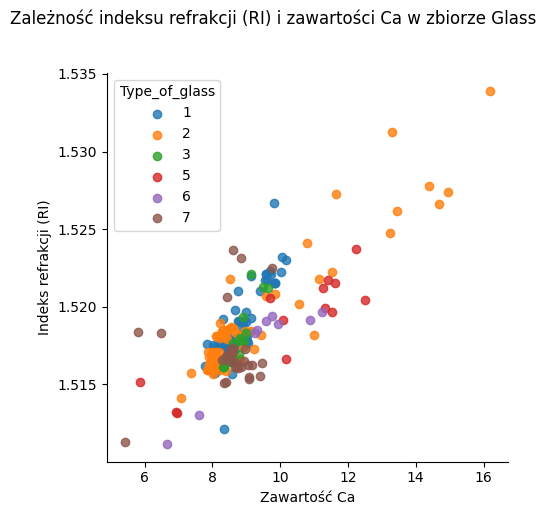

In [35]:
g = sns.lmplot(
    data=df_glass,
    x='Ca', 
    y='RI', 
    hue=df_glass.columns[-1],
    facet_kws=dict(legend_out=False),
    fit_reg=False
)
g.set_axis_labels('Zawartość Ca', 'Indeks refrakcji (RI)')
g.figure.suptitle('Zależność indeksu refrakcji (RI) i zawartości Ca w zbiorze Glass', y=1.02)
plt.tight_layout()
plt.show()


* wykres zalezności (Na, Si)

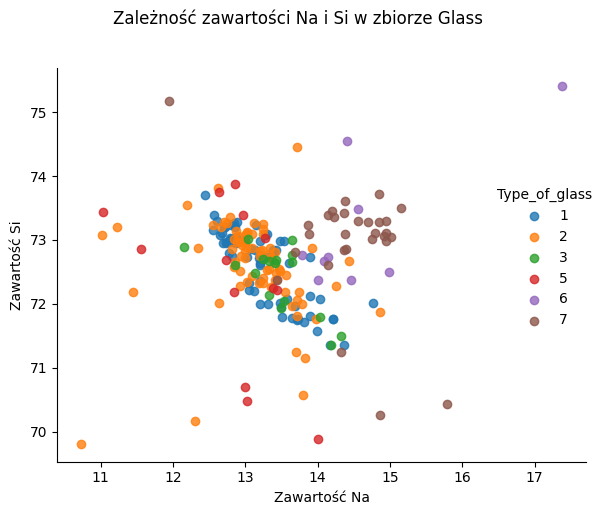

In [36]:
g = sns.lmplot(
    data=df_glass,
    x='Na', 
    y='Si', 
    hue=df_glass.columns[-1],
    facet_kws=dict(legend_out=True),
    fit_reg=False
)
g.set_axis_labels('Zawartość Na', 'Zawartość Si')
g.figure.suptitle('Zależność zawartości Na i Si w zbiorze Glass', y=1.02)
plt.tight_layout()
plt.show()

* wykres zalezności wszystkich par

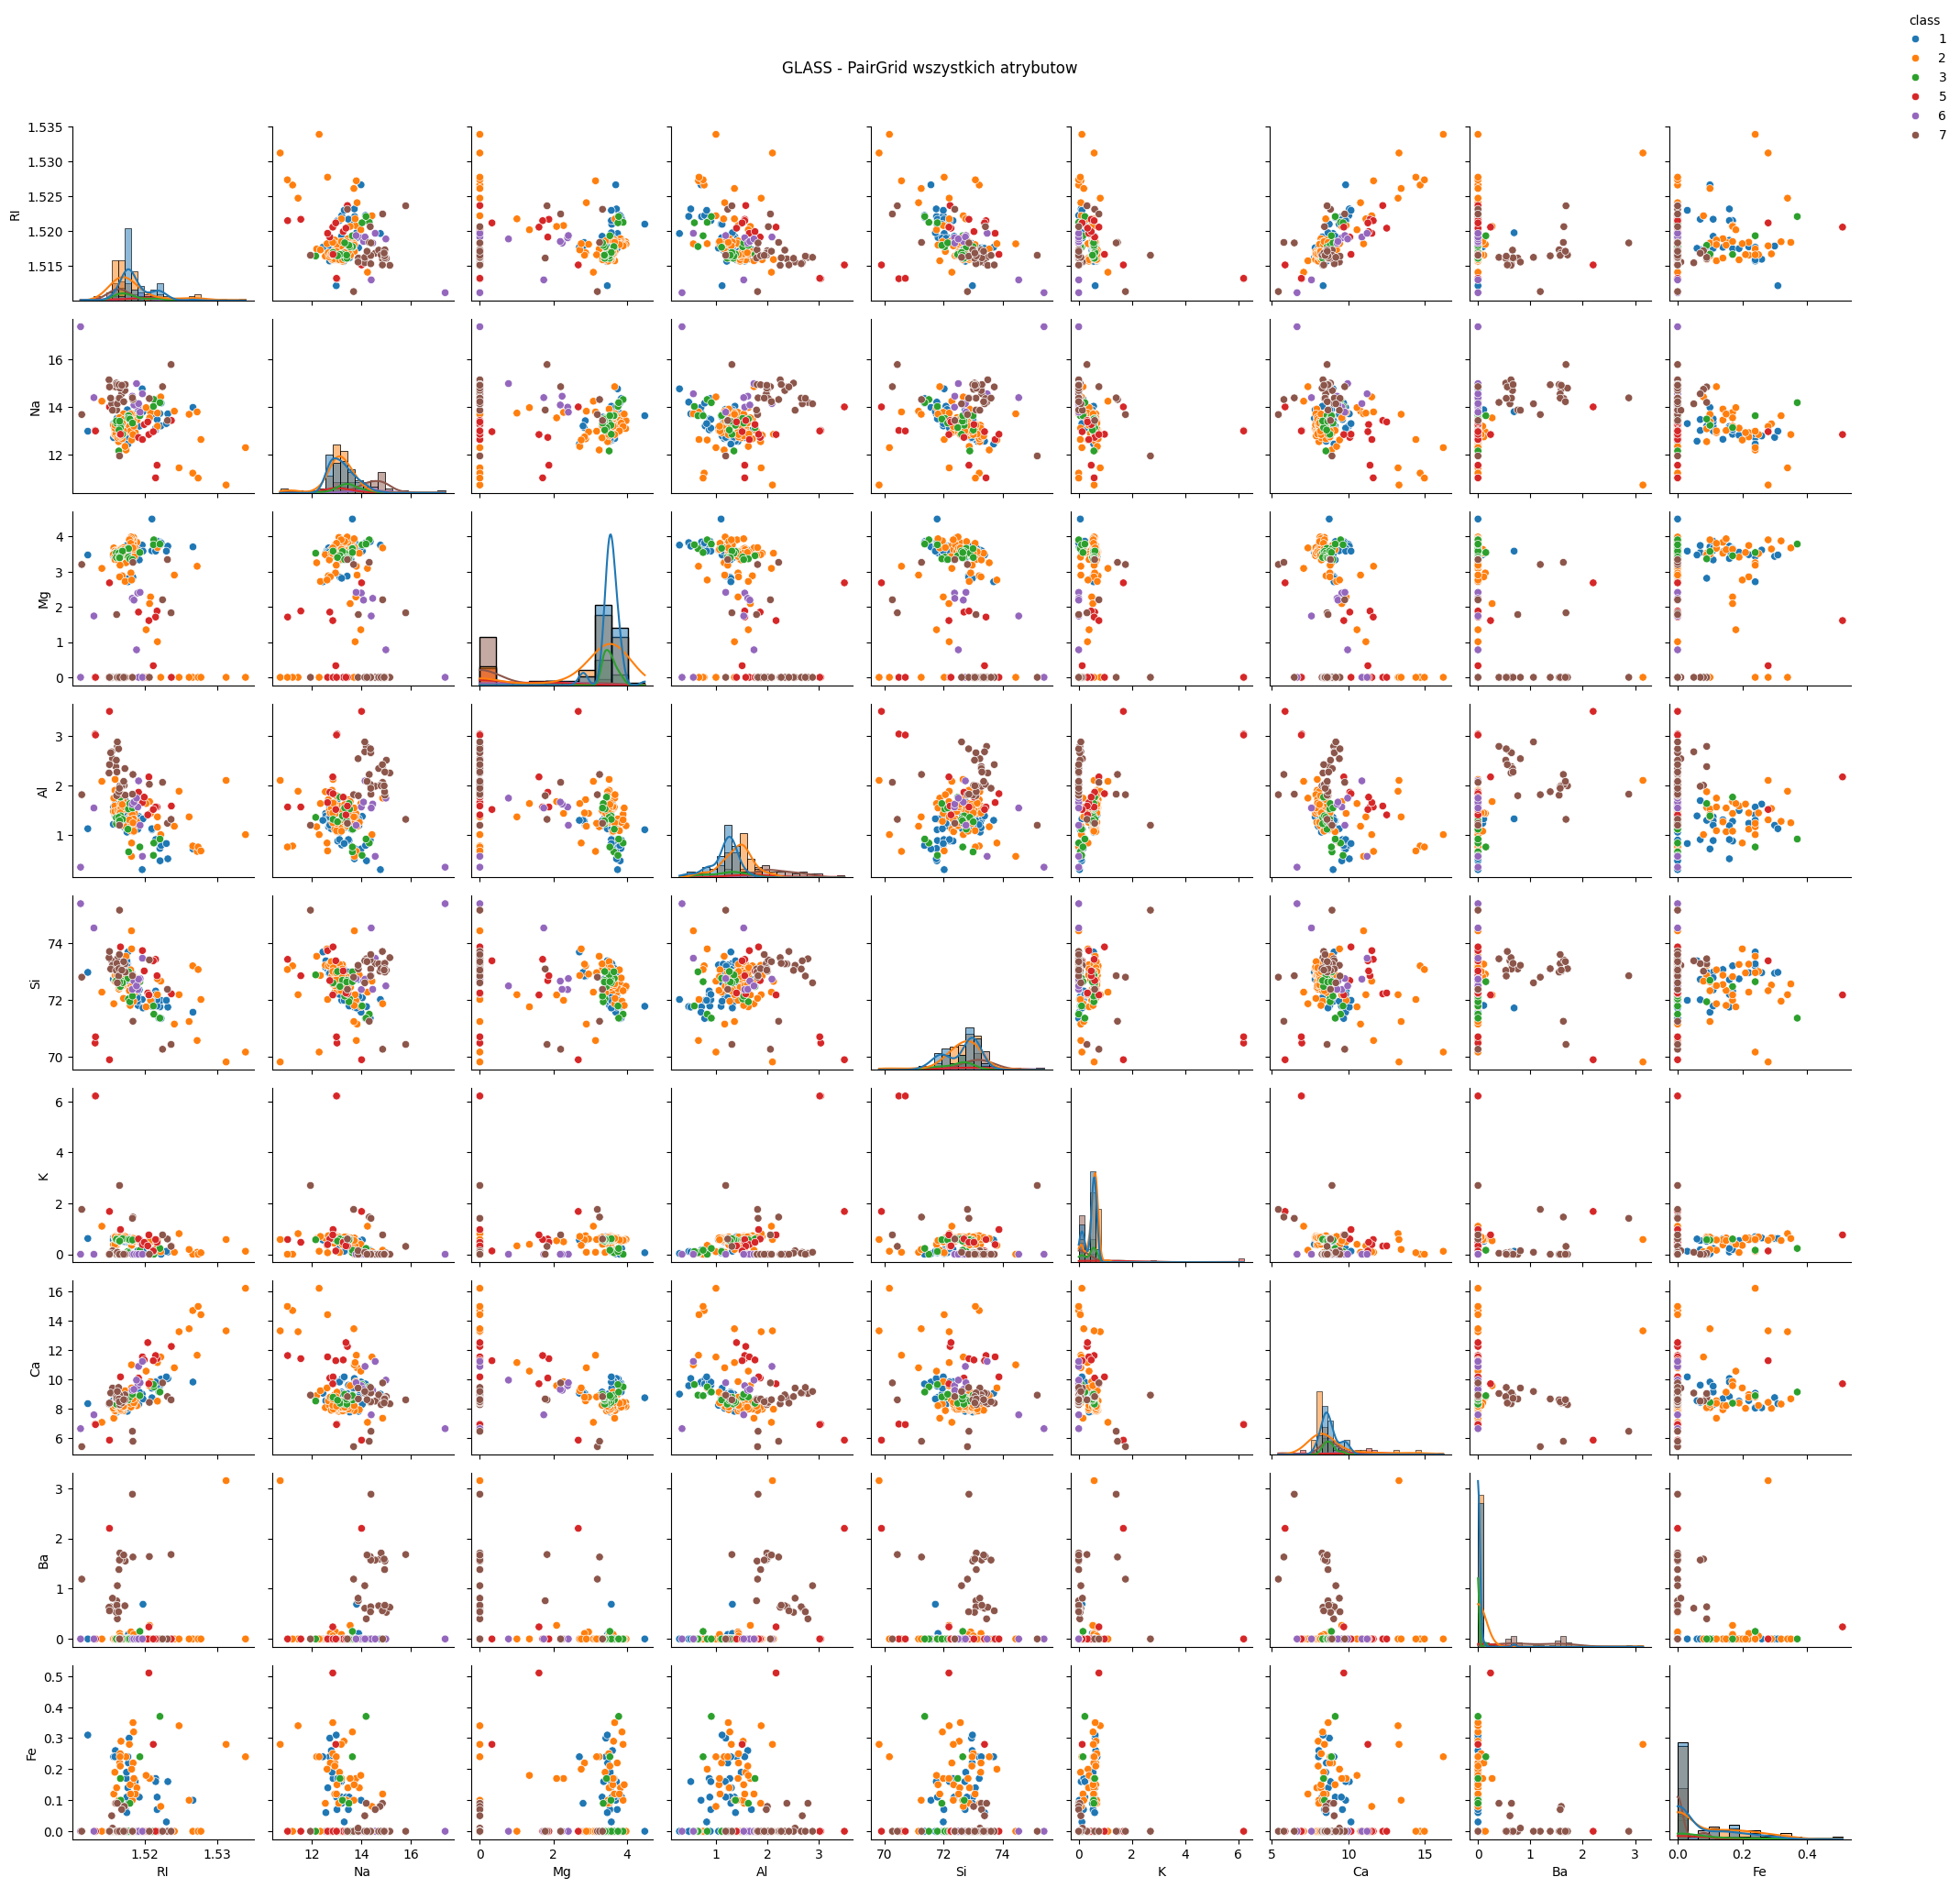

In [37]:
class_col = df_glass.columns[-1]
df_glass_plot = df_glass.copy()
df_glass_plot[class_col] = df_glass_plot[class_col].astype(str)

palette = sns.color_palette("tab10", n_colors=df_glass_plot[class_col].nunique())

g = sns.PairGrid(df_glass_plot, hue=class_col, height=2.2, palette=palette)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
g.map_diag(sns.histplot, kde=True)
g.add_legend(title='class', bbox_to_anchor=(1.05, 1))
g.figure.suptitle('GLASS - PairGrid wszystkich atrybutow', y=1.01)
plt.tight_layout()
plt.show()

-- więcej atrybutów utrudnia wizualizacje i interpretacje

-- klasy nie są wyraźnie oddzielone w przestrzeni cech

-- klasy nie tworzą odseparowanych skupisk w przestrzeni par atrybutów

-- klasy nachodzą na siebie, co sugeruje, ze zadna pojedyncza para cech nie jest wystarczająca do skutecznego sklasyfikowania

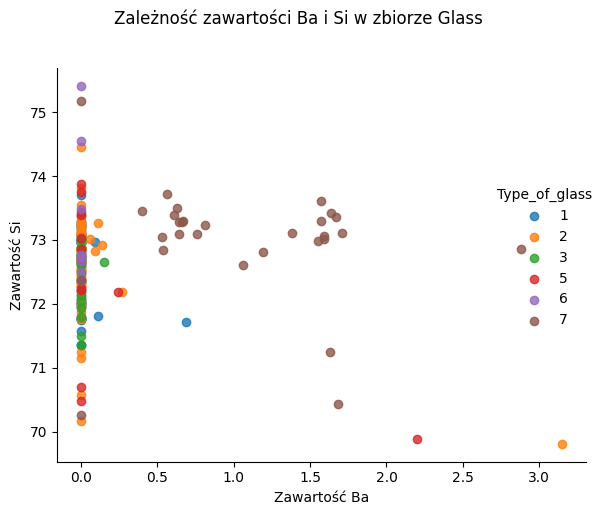

In [38]:
g = sns.lmplot(
    data=df_glass,
    x='Ba', 
    y='Si', 
    hue=df_glass.columns[-1],
    facet_kws=dict(legend_out=True),
    fit_reg=False
)
g.set_axis_labels('Zawartość Ba', 'Zawartość Si')
g.figure.suptitle('Zależność zawartości Ba i Si w zbiorze Glass', y=1.02)
plt.tight_layout()
plt.show()

In [39]:

print(f'Klasy typu 7 z zawartością Ba > 0.5: {df_glass[(df_glass.iloc[:, -1] == 7) & (df_glass["Ba"] > 0.5)].shape[0]}')
print('Procent klas typu 7 z zawartością Ba > 0.5:', round(df_glass[(df_glass.iloc[:, -1] == 7) & (df_glass['Ba'] > 0.5)].shape[0] / df_glass[df_glass.iloc[:, -1] == 7].shape[0] * 100, 2), '%')

Klasy typu 7 z zawartością Ba > 0.5: 25
Procent klas typu 7 z zawartością Ba > 0.5: 86.21 %


### 4. PCA 

Metoda redukcji wymiarowości. Szuka składowych zbierających jak najwięcej informacji

Nalezy zestandaryzować dane (średnia=0, std=1)

* Dla zbioru IRIS

PC1 wyjasnia: 72.8% wariancji
PC2 wyjasnia: 23.0% wariancji
Lacznie: 95.8% wariancji
Po PCA:
         PC1       PC2        class
0 -2.264542  0.505704  Iris-setosa
1 -2.086426 -0.655405  Iris-setosa
2 -2.367950 -0.318477  Iris-setosa
3 -2.304197 -0.575368  Iris-setosa
4 -2.388777  0.674767  Iris-setosa


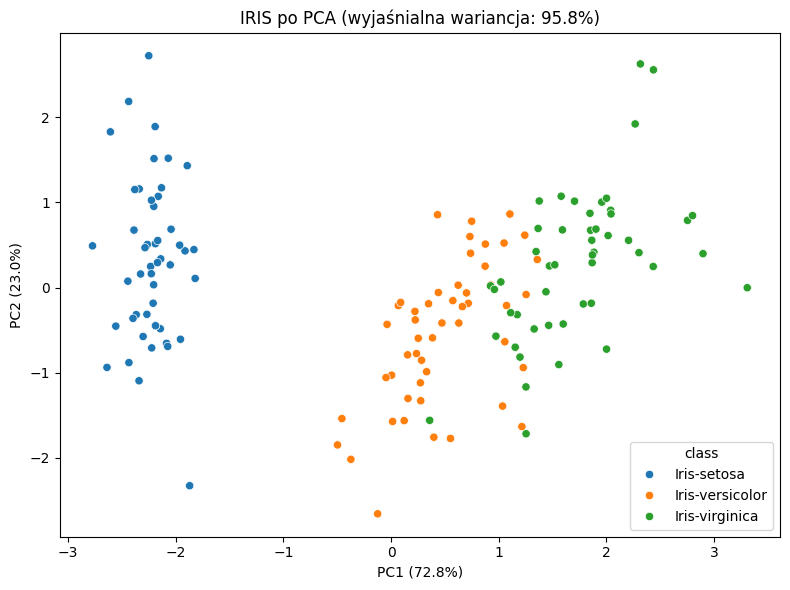

In [40]:
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

pca_iris = PCA(n_components=2)
X_iris_pca = pca_iris.fit_transform(X_iris_scaled)

# ile wariancji wyjaśnia każdy z 2 głównych komponentów
explained_variance_iris = pca_iris.explained_variance_ratio_
print(f'PC1 wyjasnia: {explained_variance_iris[0]*100:.1f}% wariancji')
print(f'PC2 wyjasnia: {explained_variance_iris[1]*100:.1f}% wariancji')
print(f'Lacznie: {sum(explained_variance_iris)*100:.1f}% wariancji')

# wyniki
df_iris_pca = pd.DataFrame(X_iris_pca, columns=['PC1', 'PC2'])
df_iris_pca['class'] = df_iris['class']

print(f'Po PCA:\n {df_iris_pca.head()}')

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_iris_pca,
    x='PC1',
    y='PC2',
    hue='class'
)
plt.title(f'IRIS po PCA (wyjaśnialna wariancja: {sum(explained_variance_iris)*100:.1f}%)')
plt.xlabel(f'PC1 ({explained_variance_iris[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance_iris[1]*100:.1f}%)')
plt.tight_layout()
plt.show()

* Dla zbioru GLASS

PC1 wyjasnia: 27.9% wariancji
PC2 wyjasnia: 22.8% wariancji
Lacznie: 50.7% wariancji
Po PCA:
         PC1       PC2 class
0  1.151140  0.529488     1
1 -0.574137  0.759788     1
2 -0.940160  0.929836     1
3 -0.142083  0.961677     1
4 -0.351092  1.091249     1


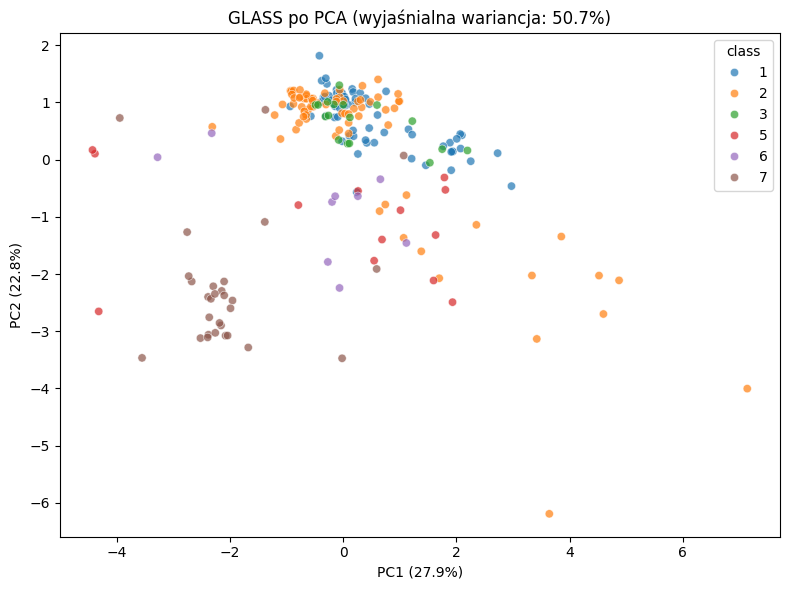

In [41]:
scaler_glass = StandardScaler()
X_glass_scaled = scaler_glass.fit_transform(X_glass)

pca_glass = PCA(n_components=2)
X_glass_pca = pca_glass.fit_transform(X_glass_scaled)

explained_variance_glass = pca_glass.explained_variance_ratio_
print(f'PC1 wyjasnia: {explained_variance_glass[0]*100:.1f}% wariancji')
print(f'PC2 wyjasnia: {explained_variance_glass[1]*100:.1f}% wariancji')
print(f'Lacznie: {sum(explained_variance_glass)*100:.1f}% wariancji')

df_glass_pca = pd.DataFrame(X_glass_pca, columns=['PC1', 'PC2'])
df_glass_pca['class'] = df_glass.iloc[:, -1].astype(str)
print(f'Po PCA:\n {df_glass_pca.head()}')

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_glass_pca,
    x='PC1',
    y='PC2',
    hue='class',
    alpha=0.7
)
plt.title(f'GLASS po PCA (wyjaśnialna wariancja: {sum(explained_variance_glass)*100:.1f}%)')
plt.xlabel(f'PC1 ({explained_variance_glass[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({explained_variance_glass[1]*100:.1f}%)')
plt.tight_layout()
plt.show()

Zredukowanie do 3 komponentów:

In [42]:
scaler_glass = StandardScaler()
X_glass_scaled = scaler_glass.fit_transform(X_glass)

pca_glass = PCA(n_components=3)
X_glass_pca = pca_glass.fit_transform(X_glass_scaled)

explained_variance_glass = pca_glass.explained_variance_ratio_
print(f'PC1 wyjasnia: {explained_variance_glass[0]*100:.1f}% wariancji')
print(f'PC2 wyjasnia: {explained_variance_glass[1]*100:.1f}% wariancji')
print(f'PC3 wyjasnia: {explained_variance_glass[2]*100:.1f}% wariancji')
print(f'Lacznie: {sum(explained_variance_glass)*100:.1f}% wariancji')

PC1 wyjasnia: 27.9% wariancji
PC2 wyjasnia: 22.8% wariancji
PC3 wyjasnia: 15.6% wariancji
Lacznie: 66.3% wariancji


Zredukowanie do 4 komponentów:

In [43]:
scaler_glass = StandardScaler()
X_glass_scaled = scaler_glass.fit_transform(X_glass)

pca_glass = PCA(n_components=4)
X_glass_pca = pca_glass.fit_transform(X_glass_scaled)

explained_variance_glass = pca_glass.explained_variance_ratio_
print(f'PC1 wyjasnia: {explained_variance_glass[0]*100:.1f}% wariancji')
print(f'PC2 wyjasnia: {explained_variance_glass[1]*100:.1f}% wariancji')
print(f'PC3 wyjasnia: {explained_variance_glass[2]*100:.1f}% wariancji')
print(f'PC4 wyjasnia: {explained_variance_glass[3]*100:.1f}% wariancji')
print(f'Lacznie: {sum(explained_variance_glass)*100:.1f}% wariancji')

df_glass_pca = pd.DataFrame(X_glass_pca, columns=['PC1', 'PC2', 'PC3', 'PC4'])
df_glass_pca['class'] = df_glass.iloc[:, -1]
print(f'Po PCA:\n {df_glass_pca.head()}')

PC1 wyjasnia: 27.9% wariancji
PC2 wyjasnia: 22.8% wariancji
PC3 wyjasnia: 15.6% wariancji
PC4 wyjasnia: 12.9% wariancji
Lacznie: 79.2% wariancji
Po PCA:
         PC1       PC2       PC3       PC4  class
0  1.151140  0.529488 -0.372096 -1.728901      1
1 -0.574137  0.759788 -0.556708 -0.760232      1
2 -0.940160  0.929836 -0.554907 -0.206254      1
3 -0.142083  0.961677 -0.117125 -0.415724      1
4 -0.351092  1.091249 -0.485079 -0.069102      1


Dla danych IRIS udało się zachować 95.6% wariancji - zróznicowania (informacji) z oryginalnych danych, czyli zredukowanie do 2D oddaje prawie całą strukturę danych. Dodatkowo pierwsza składowa daje wynik 72.8%, co oznacza ze jedna oś (jedna kombinacja tych cech) sama wyjaśnia prawie 3/4 całego zróznicowania danych (dlugosc i szerokosc platka). Otrzymane wyniki sugerują, ze oryginalne 4 cechy są silnie skorelowane - dane mają niską rzeczywistą wymiarowość. Redukcja nie gubi za bardzo zadnych informacji. 

Dla danych GLASS otrzymano 50.7%, co oznacza, ze 2 składowe zawierają połowę informacji o róznicach między klasami. Cechy są słabiej skorelowane ze sobą, więc zadne dwie składowe nie są w stanie oddać całości.

Zredukowanie do 4 zmiennych (komponentów) pozwala na wyjaśnienie około 80% wariancji całego zbioru